In [4]:
import random
import dotenv
import pathlib
import os
random.seed(2024)
dotenv.load_dotenv(override=True)
HOME_DIR = os.getenv("HOME_DIR")  # directs to gpfs in scratch

## Detect relations between optimal HPs for each sweep 

Focused on training on a random combination fo all rates at the same time - increased complexity

In [10]:
# iterate over the sweep and determine best HP combination for every (rateL, latent_size) combination
import os
import pandas as pd
import pickle
import re
from ctd.comparison.analysis.tt.tt import Analysis_TT

def parse_filename(filename, rank=False, node=False):
    """Extracts parameters from a task-trained HP tune run"""
    if rank:
        pattern = re.compile(
            r'max_epochs=\d+_weight_decay=(?P<weight_decay>\d+\.\d+E[+\-]?\d+)_learning_rate=(?P<learning_rate>\d+\.\d+E[+\-]?\d+)_noise=\d+\.\d+E[+\-]?\d+_allRates=(True|False)_seed=\d+_rank=(?P<rank>\d+)_latent_size=(?P<latent_size>\d+)'
        )
    elif node:
        pattern = re.compile(
            r'max_epochs=\d+_weight_decay=(?P<weight_decay>\d+\.\d+E[+\-]?\d+)_learning_rate=(?P<learning_rate>\d+\.\d+E[+\-]?\d+)_seed=\d+_noise=\d+\.\d+E[+\-]?\d+_allRates=(True|False)_latent_size=(?P<latent_size>\d+)_layer_hidden_size=\d+_latent_l2_wt=\d+\.\d+E[+\-]?\d+'
        )
    else:
        pattern = re.compile(
            r'max_epochs=\d+_weight_decay=(?P<weight_decay>\d+\.\d+E[+\-]?\d+)_learning_rate=(?P<learning_rate>\d+\.\d+E[+\-]?\d+)_noise=\d+\.\d+E[+\-]?\d+_allRates=(True|False)_seed=\d+_latent_size=(?P<latent_size>\d+)'
        )
    match = pattern.search(filename)
    if match and rank:
        return (
            float(match.group('weight_decay')),
            float(match.group('learning_rate')),
            int(match.group('rank')),
            int(match.group('latent_size')),
        )
    elif match:
        return (
            float(match.group('weight_decay')),
            float(match.group('learning_rate')),
            int(match.group('latent_size'))
        )
    return None

def scan_directory(root_dir, task_loss_func, rank=False, node=False):
    """Scans the directory and returns a DataFrame of losses."""
    wd_list = []
    lr_list = []
    ls_list = []
    loss_list = []
    r_list = []
    model_paths=[]
    
    # check if it exists
    if not os.path.isdir(root_dir):
        print("Sweep dir not found - change it")
    
    for subdir, _, files in os.walk(root_dir):
        model_path = os.path.join(subdir, 'model.pkl')
        if 'model.pkl' in files: # to know if training is complete
            filename = os.path.basename(subdir)
            params = parse_filename(filename, rank=rank, node=node)
            if params is None:
                print("NONE PARAMS FOUND")
                continue

            if rank:
                wd, lr, r, latent_size = params
            else:
                wd, lr, latent_size = params
            analysis = Analysis_TT(run_name = "scan", filepath = subdir + "/")
            loss = analysis.get_loss(task_loss_func)
            
            if loss is not None:
                wd_list.append(wd)
                lr_list.append(lr)
                ls_list.append(latent_size)
                loss_list.append(loss)
                model_paths.append(subdir + "/")
                if rank:
                    r_list.append(r)
            else:
                print("NULL LOSS - revise param matching")
                
    # make a dict of lists
    if rank:
        dict = {"weight_decay": wd_list, "learning_rate": lr_list, 
                "latent_size": ls_list, "rank": r_list, "loss": loss_list, "paths": model_paths}
    else:
        dict = {"weight_decay": wd_list, "learning_rate": lr_list, 
                "latent_size": ls_list, "loss": loss_list, "paths": model_paths}
    
    # Convert to DataFrame
    df = pd.DataFrame(dict)
    return df


In [12]:
# scan the fr directory for PC

from ctd.task_modeling.task_env.task_env import PClicks
pc = PClicks(n_timesteps= 500, noise= 0.1, rateL=30)  # Hz
pc_loss_func = pc.loss_func

# fr_pc_sweep = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250329_PClicks_fr_grid_test"
# df_fr = scan_directory(fr_pc_sweep, pc_loss_func)

# fr_pc_sweep_allrates = "/scratch/network/ad2002/THESIS_trained_models/20250331_PClicks_fr_grid_allRates"
# df_fr_allrates = scan_directory(fr_pc_sweep_allrates, pc_loss_func)

# lr_pc_sweep = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250329_PClicks_lr_grid_test"
# df_lr = scan_directory(lr_pc_sweep, pc_loss_func, rank=True)

# lr_pc_sweep_allrates = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250331_PClicks_lr_grid_allRates"
# df_lr_allrates = scan_directory(lr_pc_sweep_allrates, pc_loss_func, rank=True)
# index 19 is best run

node_pc_sweep_allrates = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250331_PClicks_NODE_grid_allRates"
df_node_allrates = scan_directory(node_pc_sweep_allrates, pc_loss_func, node=True)
print(df_node_allrates)

   weight_decay  learning_rate  latent_size      loss  \
0  1.000000e-08          0.002            5  0.726656   
1  1.000000e-08          0.002            3  0.238136   
2  1.000000e-08          0.002            2  0.544806   
3  1.000000e-08          0.002            3  0.514654   
4  1.000000e-08          0.002           10  0.429230   
5  1.000000e-08          0.002            5  0.215170   
6  1.000000e-08          0.002            2  0.247055   
7  1.000000e-08          0.002           10  0.769690   

                                               paths  
0  /scratch/gpfs/ad2002/content/trained_models/ta...  
1  /scratch/gpfs/ad2002/content/trained_models/ta...  
2  /scratch/gpfs/ad2002/content/trained_models/ta...  
3  /scratch/gpfs/ad2002/content/trained_models/ta...  
4  /scratch/gpfs/ad2002/content/trained_models/ta...  
5  /scratch/gpfs/ad2002/content/trained_models/ta...  
6  /scratch/gpfs/ad2002/content/trained_models/ta...  
7  /scratch/gpfs/ad2002/content/trained_models

In [3]:
# get the best hyperparams for every task difficulty
import seaborn as sns
import matplotlib.pyplot as plt

# sns.pairplot(df_fr[df_fr['rateL'] == 1])  # Creates scatter plots for all variable pairs
# plt.show()

# df = df_fr[df_fr['rateL'] == 1]
# sns.heatmap(df.corr(), annot=True, cmap="coolwarm", center=0)
# plt.show()

# from sklearn.linear_model import LinearRegression

# X = df[['learning_rate', 'batch_size', 'weight_decay', 'latent_size']]
# y = df['loss']

# model = LinearRegression()
# model.fit(X, y)

# print(f"R² Score: {model.score(X, y)}")  # How well hyperparameters explain loss
# print(f"Coefficients: {dict(zip(X.columns, model.coef_))}")  # Importance of each hyperparameter

# df = df_fr[(df_fr['rateL'] == 1) & (df_fr['loss'] <= 9e-4)]
# df = df.sort_values(by='loss')
# print("FR", df)

# df_to_save = df_fr[(df_fr['loss']<=9e-4)]
# df_to_save = df_to_save[['rateL', 'latent_size', 'loss', 'paths']]

# # Save to a CSV file
# df_to_save.to_csv("fr_sweep_1.csv", index=False)


# df = df_lr[(df_lr['rateL'] == 1) & (df_lr['loss'] <= 9e-4)]
# df = df.sort_values(by='loss')
# print("LR", df)

# df_to_save = df_node_allrates[(df_node_allrates['loss']<=10)]
# df_to_save = df_to_save[['rateL', 'latent_size', 'rank', 'loss', 'paths']]
# print(df_to_save)
# # Save to a CSV file
# df_to_save.to_csv("node_sweep_all_1.csv", index=False)

# print(df_fr)
# print(df_lr)

Empty DataFrame
Columns: [weight_decay, learning_rate, latent_size, loss, paths]
Index: []


## Study training dynamics - effects of different HPs

* If 2 HPs are very similar in final loss, choose the best monotonically decreasing one
* Determine good epoch lim

tune params:  53_env_params_noise=0.0500,env_params_rateL=1,model_latent_size=5
final loss:  1.5405230442411266e-05
completed?  True


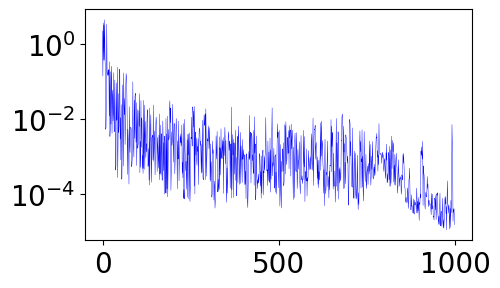

tune params:  54_env_params_noise=0,env_params_rateL=39,model_latent_size=10
final loss:  0.0003610342682804
completed?  True


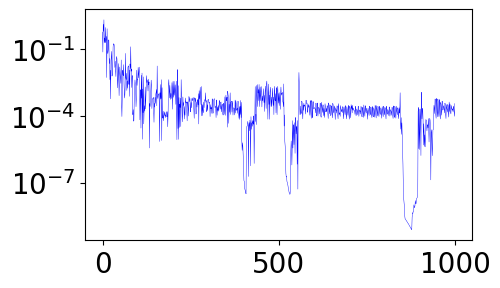

tune params:  41_env_params_noise=0.0500,env_params_rateL=32,model_latent_size=5
final loss:  0.3151213228702545
completed?  True


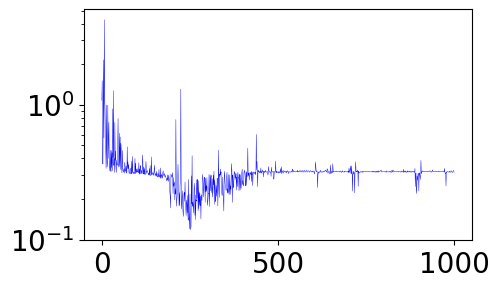

tune params:  44_env_params_noise=0.0500,env_params_rateL=26,model_latent_size=5
final loss:  0.0010540853254497
completed?  True


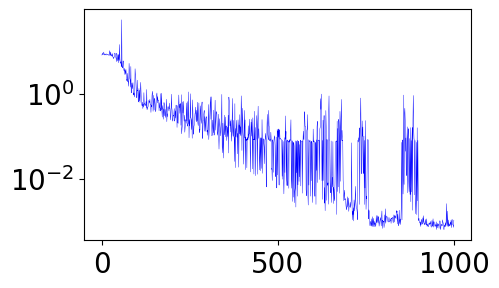

tune params:  14_env_params_noise=0.0500,env_params_rateL=8,model_latent_size=2
final loss:  0.871786892414093
completed?  True


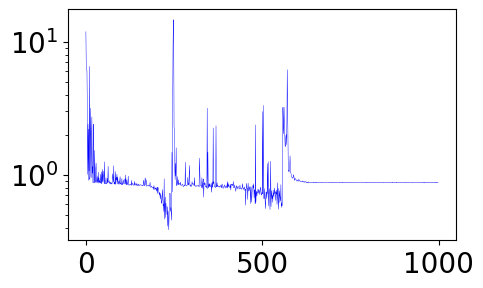

tune params:  19_env_params_noise=0,env_params_rateL=39,model_latent_size=3
final loss:  5.6908596945959295e-08
completed?  True


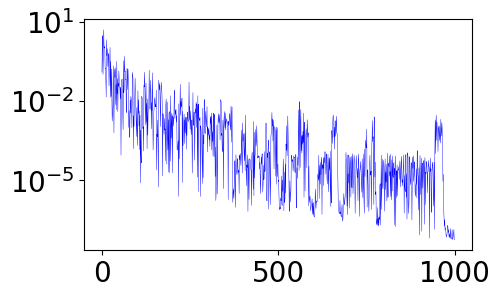

tune params:  1_env_params_noise=0,env_params_rateL=39,model_latent_size=2
final loss:  5.3484065176689917e-08
completed?  True


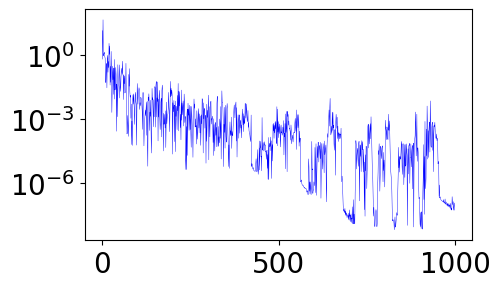

tune params:  23_env_params_noise=0.0500,env_params_rateL=32,model_latent_size=3
final loss:  0.3986689448356628
completed?  True


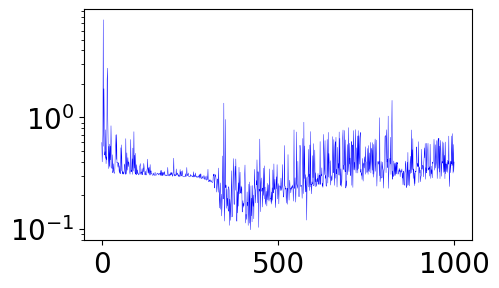

tune params:  6_env_params_noise=0,env_params_rateL=26,model_latent_size=2
final loss:  9.910581866279244e-05
completed?  True


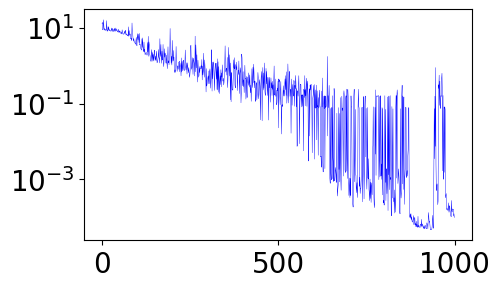

tune params:  15_env_params_noise=0,env_params_rateL=1,model_latent_size=2
final loss:  1.3797243809676727e-05
completed?  True


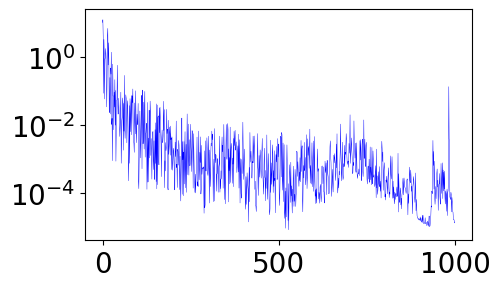

tune params:  33_env_params_noise=0,env_params_rateL=1,model_latent_size=3
final loss:  7.248252131830668e-06
completed?  True


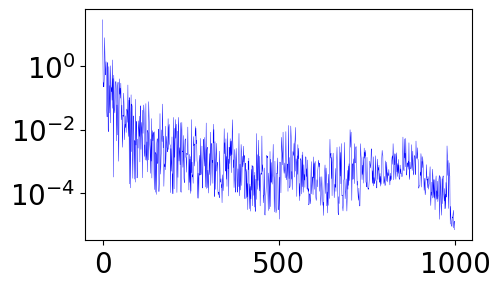

tune params:  51_env_params_noise=0,env_params_rateL=1,model_latent_size=5
final loss:  1.954931030923035e-05
completed?  True


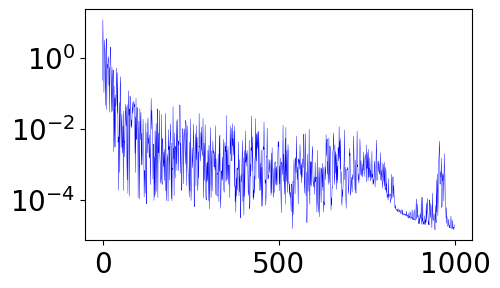

tune params:  7_env_params_noise=0,env_params_rateL=26,model_latent_size=2
final loss:  9.910581866279244e-05
completed?  True


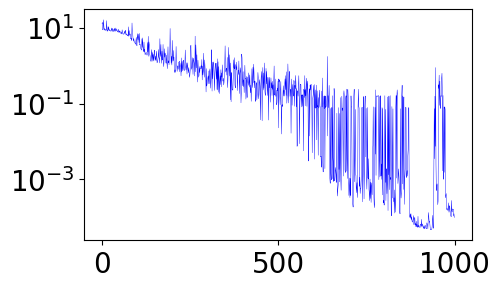

tune params:  38_env_params_noise=0.0500,env_params_rateL=39,model_latent_size=5
final loss:  4.286507191864075e-06
completed?  True


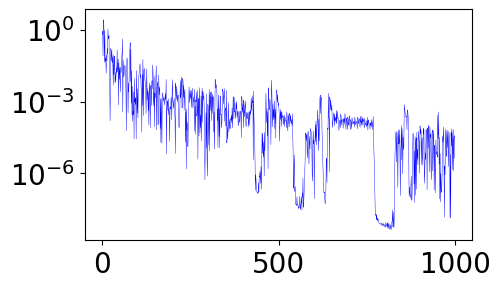

tune params:  47_env_params_noise=0.0500,env_params_rateL=14,model_latent_size=5
final loss:  0.0031091975979506
completed?  True


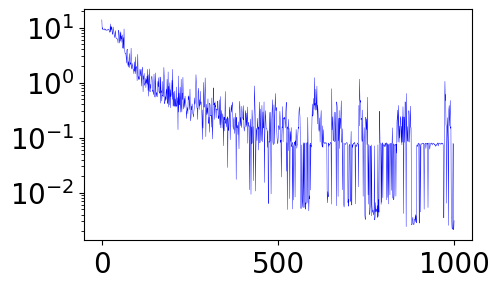

tune params:  55_env_params_noise=0,env_params_rateL=39,model_latent_size=10
final loss:  0.0003610342682804
completed?  True


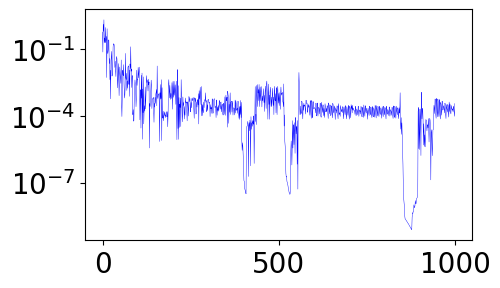

tune params:  37_env_params_noise=0,env_params_rateL=39,model_latent_size=5
final loss:  2.8191861929371957e-06
completed?  True


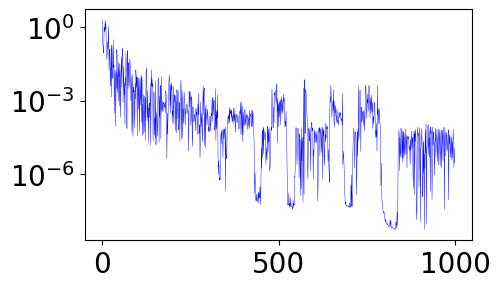

tune params:  10_env_params_noise=0,env_params_rateL=14,model_latent_size=2
final loss:  0.0001130704331444
completed?  True


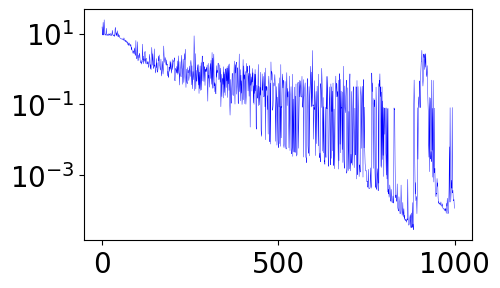

tune params:  36_env_params_noise=0,env_params_rateL=39,model_latent_size=5
final loss:  2.8191861929371957e-06
completed?  True


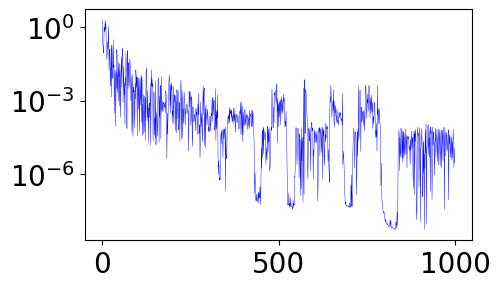

tune params:  57_env_params_noise=0,env_params_rateL=32,model_latent_size=10
final loss:  0.3236332237720489
completed?  False


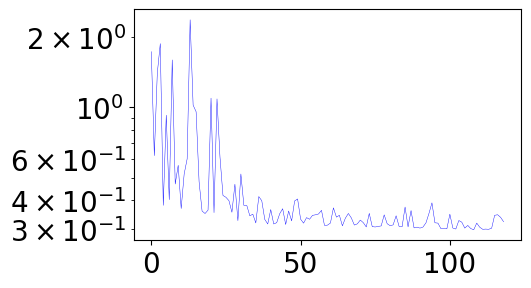

tune params:  45_env_params_noise=0,env_params_rateL=14,model_latent_size=5
final loss:  0.0857509523630142
completed?  True


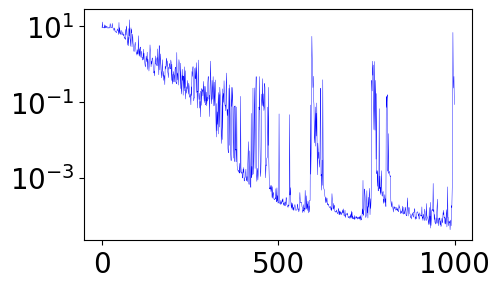

tune params:  40_env_params_noise=0,env_params_rateL=32,model_latent_size=5
final loss:  0.2282745987176895
completed?  True


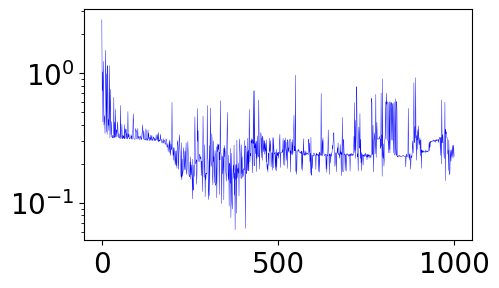

tune params:  8_env_params_noise=0.0500,env_params_rateL=26,model_latent_size=2
final loss:  0.2404198050498962
completed?  True


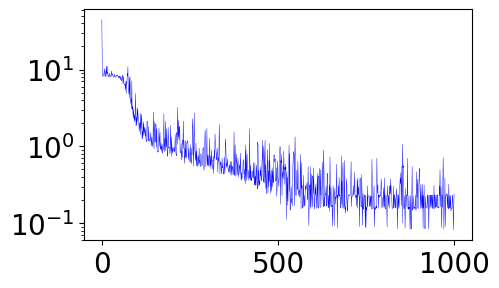

tune params:  24_env_params_noise=0,env_params_rateL=26,model_latent_size=3
final loss:  3.497646321193315e-05
completed?  True


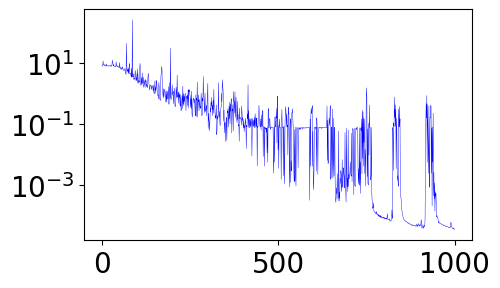

tune params:  2_env_params_noise=0.0500,env_params_rateL=39,model_latent_size=2
final loss:  1.2799995374734865e-06
completed?  True


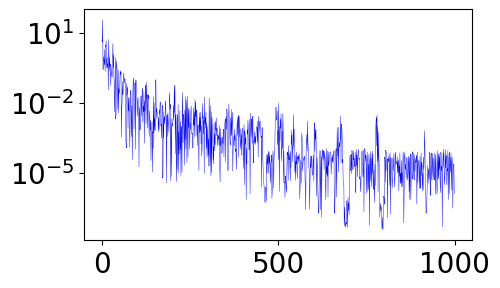

tune params:  20_env_params_noise=0.0500,env_params_rateL=39,model_latent_size=3
final loss:  7.63754087529378e-06
completed?  True


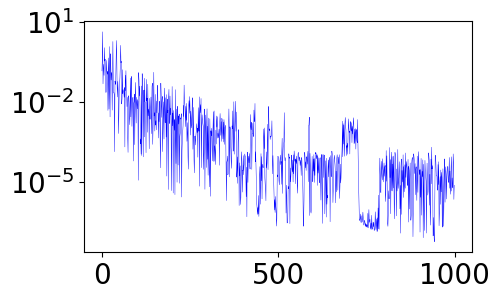

tune params:  35_env_params_noise=0.0500,env_params_rateL=1,model_latent_size=3
final loss:  0.0003161714994348
completed?  True


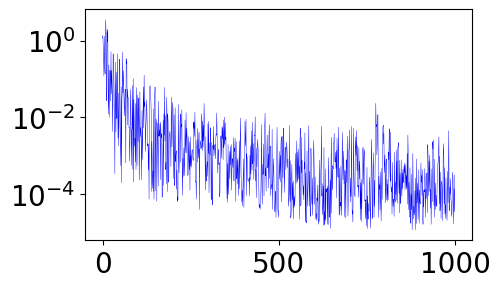

tune params:  46_env_params_noise=0,env_params_rateL=14,model_latent_size=5
final loss:  0.0857509523630142
completed?  True


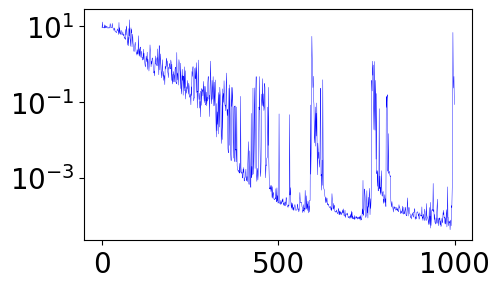

tune params:  17_env_params_noise=0.0500,env_params_rateL=1,model_latent_size=2
final loss:  3.423068847041577e-05
completed?  True


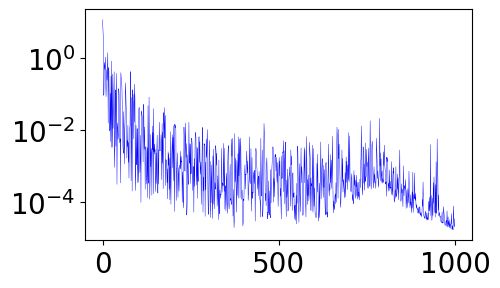

tune params:  26_env_params_noise=0.0500,env_params_rateL=26,model_latent_size=3
final loss:  0.0827282965183258
completed?  True


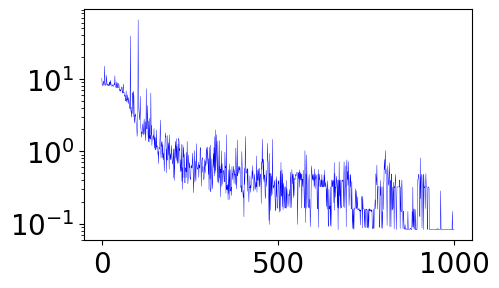

tune params:  48_env_params_noise=0,env_params_rateL=8,model_latent_size=5
final loss:  0.1417329162359237
completed?  True


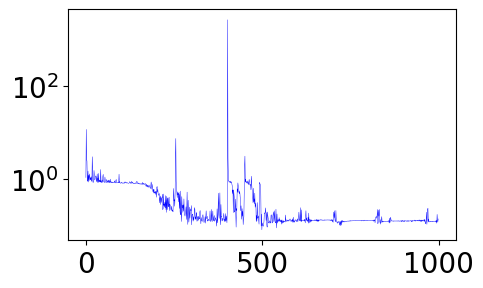

tune params:  32_env_params_noise=0.0500,env_params_rateL=8,model_latent_size=3
final loss:  0.0828110203146934
completed?  True


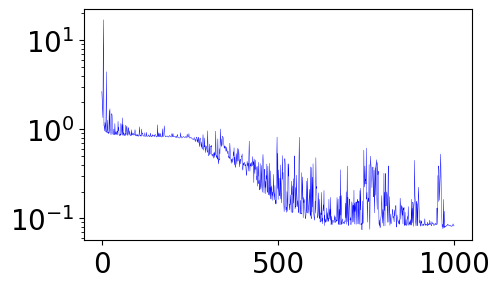

tune params:  13_env_params_noise=0,env_params_rateL=8,model_latent_size=2
final loss:  0.1270464956760406
completed?  True


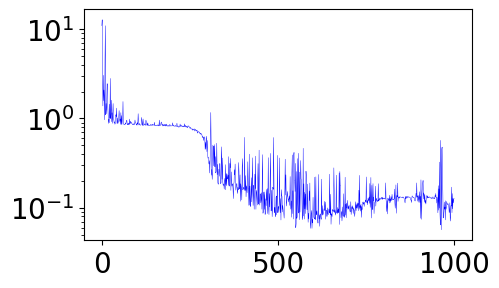

tune params:  21_env_params_noise=0,env_params_rateL=32,model_latent_size=3
final loss:  0.3337891101837158
completed?  True


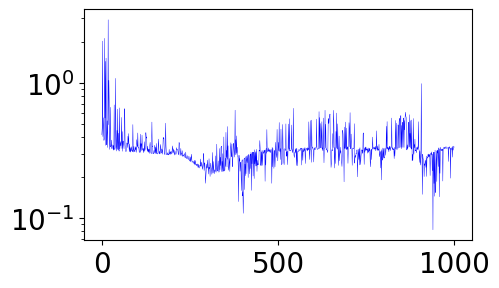

tune params:  11_env_params_noise=0.0500,env_params_rateL=14,model_latent_size=2
final loss:  nan
completed?  True


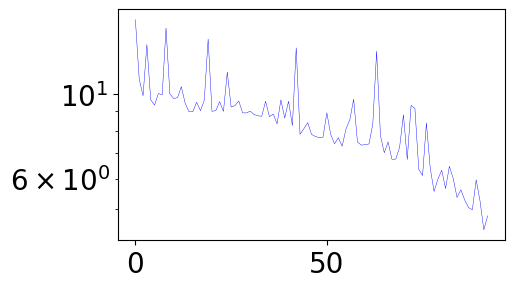

tune params:  49_env_params_noise=0,env_params_rateL=8,model_latent_size=5
final loss:  0.1417329162359237
completed?  True


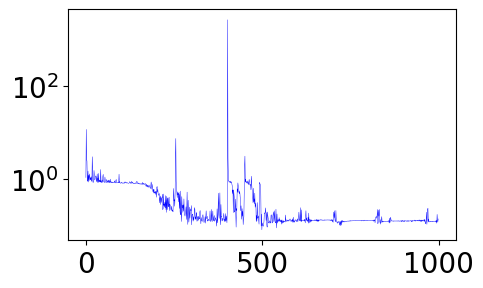

tune params:  12_env_params_noise=0,env_params_rateL=8,model_latent_size=2
final loss:  0.1270464956760406
completed?  True


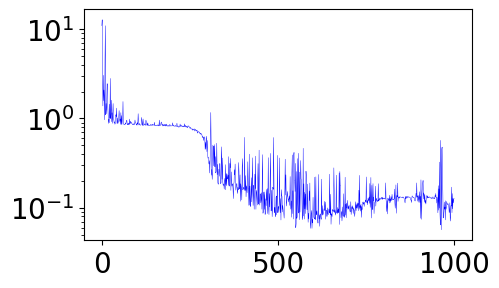

tune params:  22_env_params_noise=0,env_params_rateL=32,model_latent_size=3
final loss:  0.3337891101837158
completed?  True


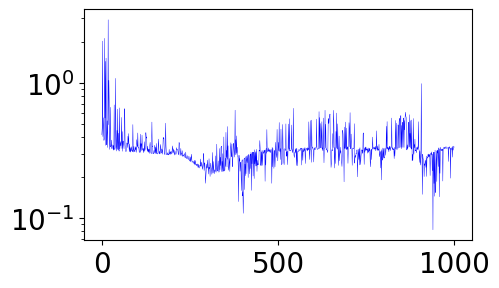

tune params:  29_env_params_noise=0.0500,env_params_rateL=14,model_latent_size=3
final loss:  0.1591048389673233
completed?  True


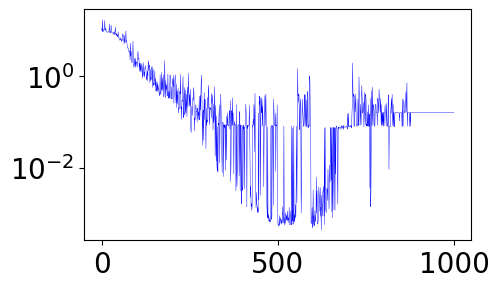

tune params:  27_env_params_noise=0,env_params_rateL=14,model_latent_size=3
final loss:  0.0001658817345742
completed?  True


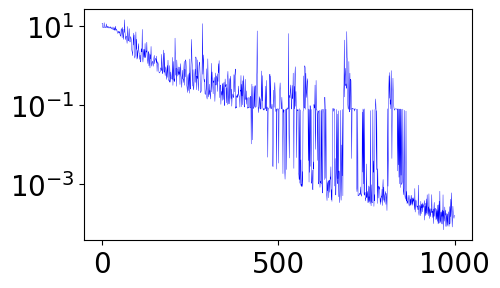

tune params:  42_env_params_noise=0,env_params_rateL=26,model_latent_size=5
final loss:  0.2320455759763717
completed?  True


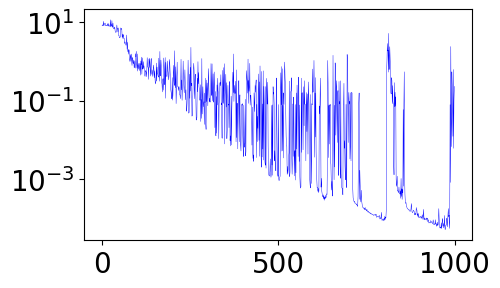

tune params:  9_env_params_noise=0,env_params_rateL=14,model_latent_size=2
final loss:  0.0001130704331444
completed?  True


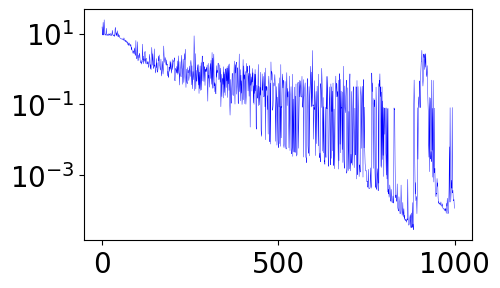

tune params:  16_env_params_noise=0,env_params_rateL=1,model_latent_size=2
final loss:  1.3797243809676727e-05
completed?  True


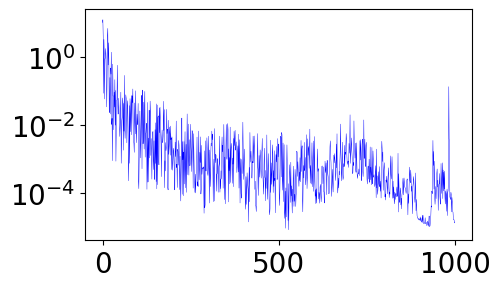

tune params:  58_env_params_noise=0,env_params_rateL=32,model_latent_size=10
final loss:  0.3123061060905456
completed?  False


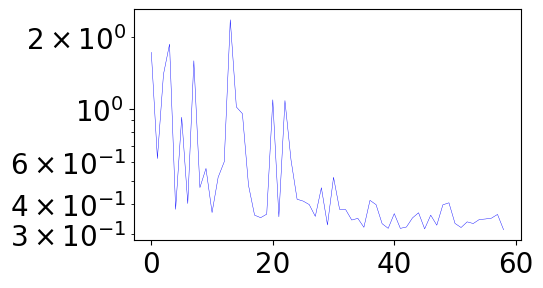

tune params:  3_env_params_noise=0,env_params_rateL=32,model_latent_size=2
final loss:  0.3876616954803467
completed?  True


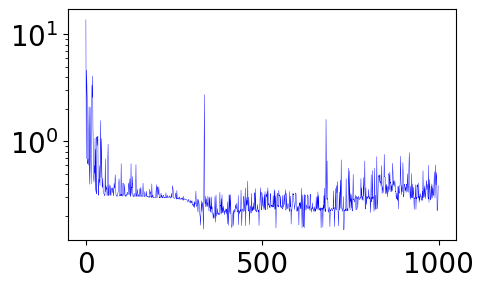

tune params:  5_env_params_noise=0.0500,env_params_rateL=32,model_latent_size=2
final loss:  0.1132733821868896
completed?  True


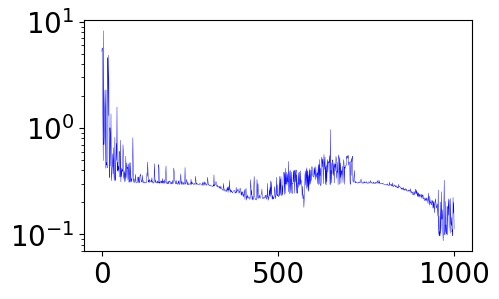

tune params:  56_env_params_noise=0.0500,env_params_rateL=39,model_latent_size=10
final loss:  0.000643866835162
completed?  False


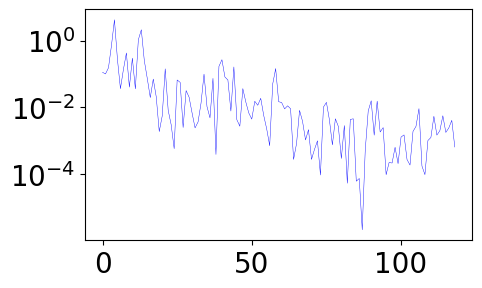

tune params:  50_env_params_noise=0.0500,env_params_rateL=8,model_latent_size=5
final loss:  0.3124626874923706
completed?  True


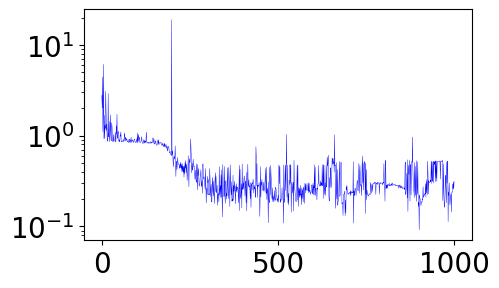

tune params:  43_env_params_noise=0,env_params_rateL=26,model_latent_size=5
final loss:  0.2320455759763717
completed?  True


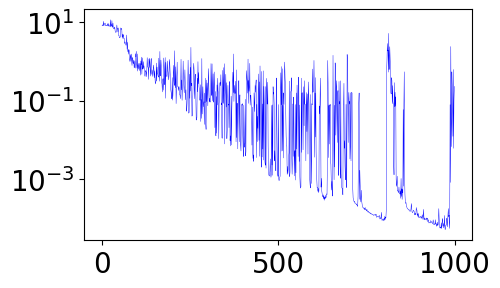

tune params:  30_env_params_noise=0,env_params_rateL=8,model_latent_size=3
final loss:  0.1051472723484039
completed?  True


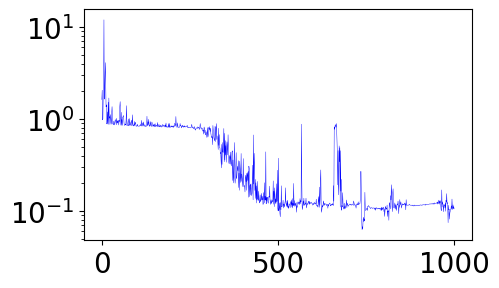

tune params:  52_env_params_noise=0,env_params_rateL=1,model_latent_size=5
final loss:  1.954931030923035e-05
completed?  True


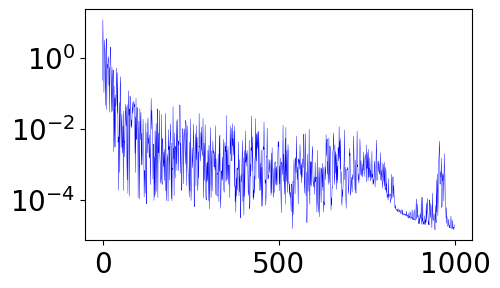

tune params:  18_env_params_noise=0,env_params_rateL=39,model_latent_size=3
final loss:  5.6908596945959295e-08
completed?  True


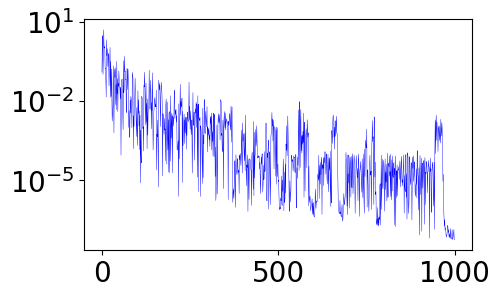

tune params:  28_env_params_noise=0,env_params_rateL=14,model_latent_size=3
final loss:  0.0001658817345742
completed?  True


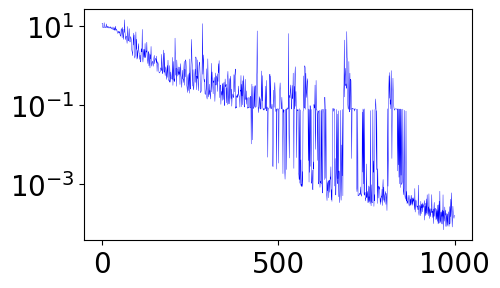

tune params:  4_env_params_noise=0,env_params_rateL=32,model_latent_size=2
final loss:  0.3876616954803467
completed?  True


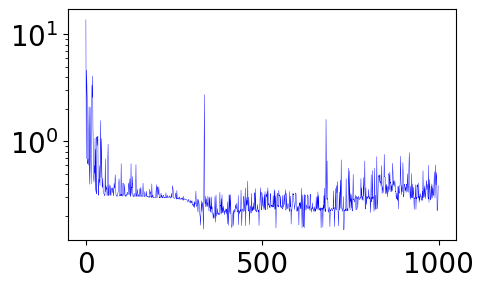

tune params:  59_env_params_noise=0.0500,env_params_rateL=32,model_latent_size=10
final loss:  0.3266475796699524
completed?  False


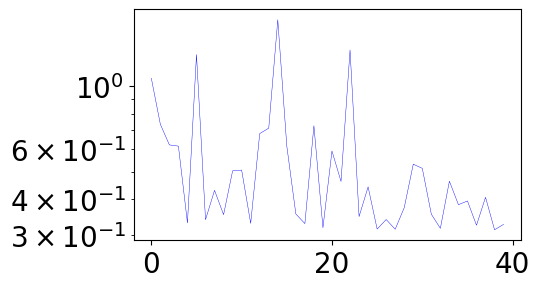

tune params:  31_env_params_noise=0,env_params_rateL=8,model_latent_size=3
final loss:  0.1051472723484039
completed?  True


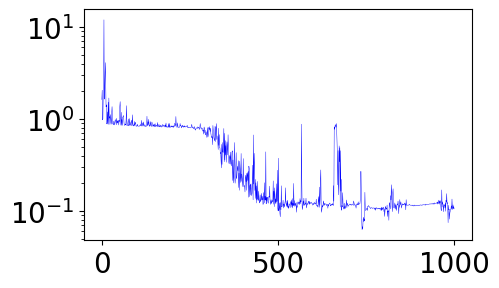

tune params:  34_env_params_noise=0,env_params_rateL=1,model_latent_size=3
final loss:  7.248252131830668e-06
completed?  True


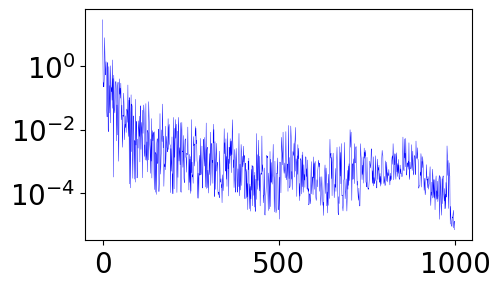

tune params:  39_env_params_noise=0,env_params_rateL=32,model_latent_size=5
final loss:  0.2282745987176895
completed?  True


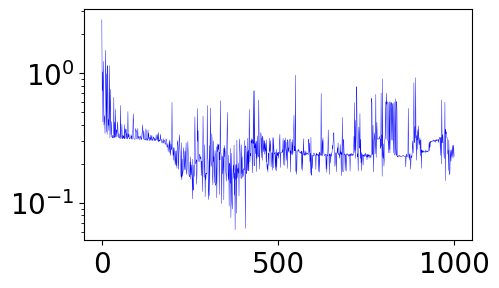

tune params:  0_env_params_noise=0,env_params_rateL=39,model_latent_size=2
final loss:  5.3484065176689917e-08
completed?  True


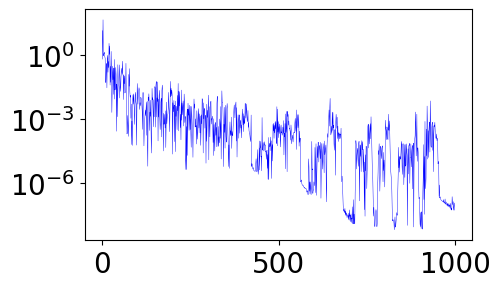

tune params:  25_env_params_noise=0,env_params_rateL=26,model_latent_size=3
final loss:  3.497646321193315e-05
completed?  True


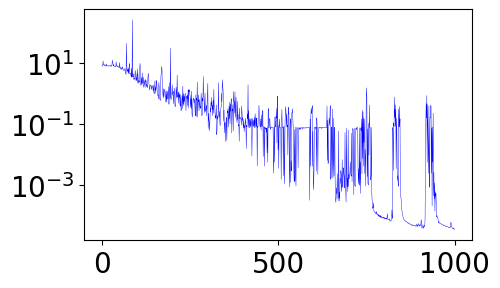

53_env_params_noise=0.0500,env_params_rateL=1,model_latent_size=5

19_env_params_noise=0,env_params_rateL=39,model_latent_size=3

1_env_params_noise=0,env_params_rateL=39,model_latent_size=2

6_env_params_noise=0,env_params_rateL=26,model_latent_size=2

15_env_params_noise=0,env_params_rateL=1,model_latent_size=2

33_env_params_noise=0,env_params_rateL=1,model_latent_size=3

51_env_params_noise=0,env_params_rateL=1,model_latent_size=5

7_env_params_noise=0,env_params_rateL=26,model_latent_size=2

38_env_params_noise=0.0500,env_params_rateL=39,model_latent_size=5

37_env_params_noise=0,env_params_rateL=39,model_latent_size=5

36_env_params_noise=0,env_params_rateL=39,model_latent_size=5

24_env_params_noise=0,env_params_rateL=26,model_latent_size=3

2_env_params_noise=0.0500,env_params_rateL=39,model_latent_size=2

20_env_params_noise=0.0500,env_params_rateL=39,model_latent_size=3

17_env_params_noise=0.0500,env_params_rateL=1,model_latent_size=2

16_env_params_noise=0,env_params_rateL=

In [7]:
# iterate over all tune runs and
# 1. create analysis folders
# 2. print the final val/train loss for each + the training dynamics
# 2. plot the trial io AND flow field + latents
# 3. select the best ones

import os
import pandas as pd
import matplotlib.pyplot as plt
import json

RUN_DIR = "/scratch/gpfs/ad2002/content/runs/task-trained/20250323_PClicks_NODE_grid"
TRAINED_MODELS_DIR = ""

TOTAL_ITERS = 1000
SHOW_LOSS_CURVES = True
FLOW_FIELD = False

dirs = os.listdir(RUN_DIR)
# retrieve the last training for that model and task
latest_dir = dirs[len(dirs)-2]
# get all hyperparam combs for the latest train run
tunes = os.listdir(RUN_DIR + "/" + latest_dir)
good_loss = []

for tune in tunes:
    
    prog_path = RUN_DIR + "/" + latest_dir + "/" + tune + '/progress.csv'
    params_path = RUN_DIR + "/" + latest_dir + "/" + tune + '/params.json'
    if os.path.exists(prog_path):
        df = pd.read_csv(prog_path)
        loss = df.iloc[:, 0]
        print("tune params: ", tune)
        print("final loss: ", loss[len(loss)-1])
        print("completed? ", len(loss) == TOTAL_ITERS)

        if loss[len(loss)-1] <= 1e-4:
            good_loss.append(tune)
              
        if SHOW_LOSS_CURVES:
            fig, ax = plt.subplots(figsize=(5, 3), dpi=100)
            ax.plot(loss, linestyle="-", color="b", label="val loss", linewidth=0.3)
            ax.set_yscale('log')
            plt.show()

        if FLOW_FIELD:
            # create analysis object
            pass

for word in good_loss:
    print(word + '\n')


In [8]:
from ctd.comparison.analysis.tt.tt import Analysis_TT

# path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250327_2BFF_NODE_verify/max_epochs=200_batch_size=128_weight_decay=1.00E-10_learning_rate=1.00E-03_seed=0_noise=5.00E-02_latent_size=3_layer_hidden_size=128_n=2"
# ver_node = Analysis_TT(run_name = "ver_node", filepath = path + "/")
# # ver_node.plot_trial_latents()

# path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250312_3BFF_frRNN/max_epochs=1000_weight_decay=1.00E-06_learning_rate=1.00E-02_seed=0_noise=0.00E+00_latent_size=64"
# ver_fr = Analysis_TT(run_name = "ver_fr", filepath = path + "/")
# ver_fr.plot_trial_latents(n_components = 2)

# path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250329_3BFF_frRNN_testFP/max_epochs=24_weight_decay=1.00E-06_learning_rate=5.00E-03_seed=0_noise=0.00E+00_latent_size=256"
# ver_fr_pc = Analysis_TT(run_name = "ver_fr_pc", filepath = path + "/")

path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250329_3BFF_lrRNN_testFP/max_epochs=50_weight_decay=1.00E-06_learning_rate=1.00E-03_seed=0_noise=0.00E+00_latent_size=256_rank=2"
ver_lr_3bff = Analysis_TT(run_name = "ver_lr_pc", filepath = path + "/")

# print(ver_lr_3bff.wrapper.model.cell.recW1.weight)

## Verify methods w known NBFF results

All good - flow field not the best bc NODE model was not fully optimized

/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")



Iteration 500/10000
q = 7.60E-03 +/- 3.85E-02
dq = 6.02E-06 +/- 2.87E-05

Iteration 1000/10000
q = 6.57E-03 +/- 3.35E-02
dq = 8.59E-07 +/- 5.09E-06

Iteration 1500/10000
q = 6.05E-03 +/- 3.10E-02
dq = 1.36E-06 +/- 7.94E-06

Iteration 2000/10000
q = 5.11E-03 +/- 2.67E-02
dq = 2.46E-06 +/- 1.42E-05

Iteration 2500/10000
q = 3.63E-03 +/- 2.01E-02
dq = 3.26E-06 +/- 1.86E-05

Iteration 3000/10000
q = 2.04E-03 +/- 1.27E-02
dq = 3.01E-06 +/- 1.79E-05

Iteration 3500/10000
q = 7.88E-04 +/- 5.31E-03
dq = 1.80E-06 +/- 1.29E-05

Iteration 4000/10000
q = 2.42E-04 +/- 1.49E-03
dq = 5.49E-07 +/- 4.49E-06

Iteration 4500/10000
q = 8.63E-05 +/- 5.31E-04
dq = 1.71E-07 +/- 9.98E-07

Iteration 5000/10000
q = 2.98E-05 +/- 1.91E-04
dq = 7.03E-08 +/- 4.90E-07

Iteration 5500/10000
q = 9.56E-06 +/- 5.92E-05
dq = 2.06E-08 +/- 1.28E-07

Iteration 6000/10000
q = 4.14E-06 +/- 2.54E-05
dq = 7.44E-09 +/- 4.38E-08

Iteration 6500/10000
q = 2.12E-06 +/- 1.07E-05
dq = 4.62E-09 +/- 2.11E-08

Iteration 7000/10000
q = 

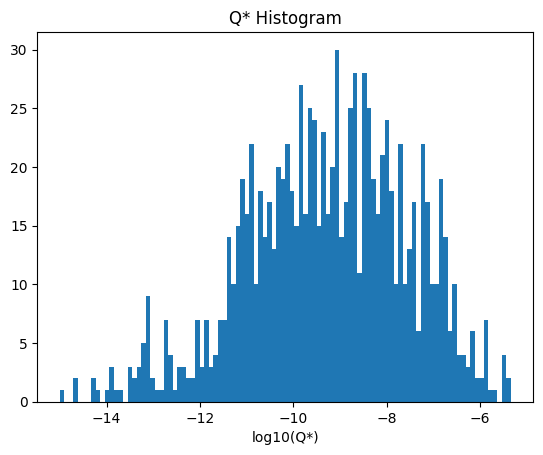

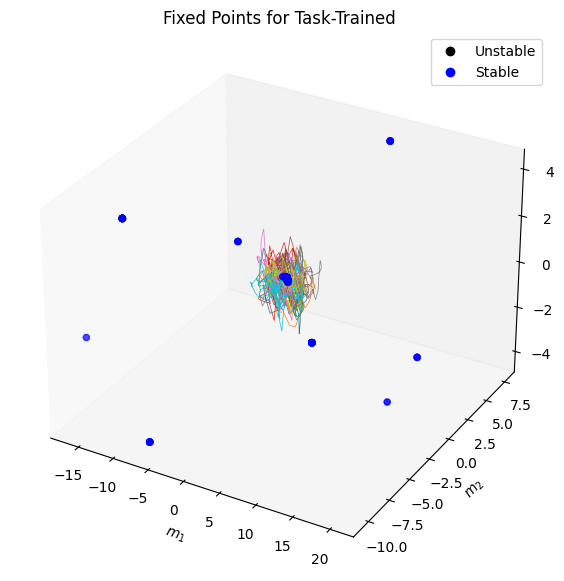

In [2]:
# print(ver_fr_pc.wrapper.model)
# running on 48 G - 12 cores

fps, xstar, q_flag, colors = ver_lr_pc.plot_fps(
                    num_traj=10,
                    n_inits=1024,
                    noise_scale=0.0,
                    learning_rate=1e-3,
                    max_iters=10000,
                    device="cpu",
                    seed=0,
                    compute_jacobians=True,
                    q_thresh=1e-3,
                    n_pca_components=3,
                    return_pca_model = False,
                    do_pca=True,
                    plot_only_points=False,
                    return_points = True,
                )

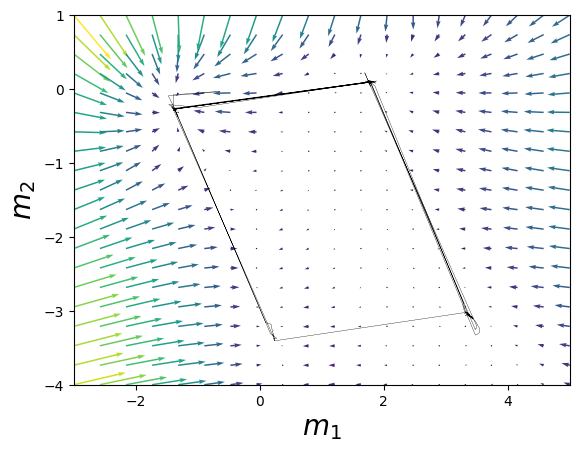

In [2]:
from ctd.comparison.analysis.tt.tt import Analysis_TT
import matplotlib.pyplot as plt
import torch

# path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250312_3BFF_NODE/max_epochs=1000_weight_decay=1.00E-10_learning_rate=1.00E-02_seed=0_noise=1.00E-01_latent_size=3_layer_hidden_size=64"
# node_3bff = Analysis_TT(run_name = "node_3bff", filepath = path + "/")

# path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250319_3BFF_full_testFP/max_epochs=500_weight_decay=1.00E-08_learning_rate=5.00E-03_seed=0_noise=5.00E-02_latent_size=128"
# full_3bff = Analysis_TT(run_name = "full_3bff", filepath = path + "/")

# node_3bff.plot_trial_io(num_trials = 2)
# node_3bff.plot_trial_latents(num_trials = 10)

# testing if FP finder works for FullRankRNN and LowRankRNN - GOOD
# fps, xstar, q_flag, colors = node_3bff.plot_fps(
#                     num_traj=10,
#                     n_inits=1024,
#                     noise_scale=0.0,
#                     learning_rate=1e-3,
#                     max_iters=10000,
#                     device="cpu",
#                     seed=0,
#                     compute_jacobians=True,
#                     q_thresh=1e-3,
#                     n_pca_components=3,
#                     return_pca_model = False,
#                     do_pca=False,
#                     plot_only_points=False,
#                     return_points = True,
#                 )

path_ver = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250328_2BFF_NODE_verify/max_epochs=400_batch_size=128_weight_decay=1.00E-10_learning_rate=1.00E-03_seed=0_noise=5.00E-02_latent_size=2_layer_hidden_size=128_n=2"
verify = Analysis_TT(run_name = "ver", filepath = path_ver + "/")

# dimension of inputs should be 2 - 2BFF
verify.plot_flow_field(latents_range = [[-3,5],[-4,1]], num_points = 20, inputs = torch.tensor([0,0]).unsqueeze(0), xstar=None, 
                        q_flag=None, colors_fps=None, num_traj=2, cmap=plt.cm.viridis, scatter_trajectories=False,
                        params = None, noiseless=False)

## Poisson clicks task

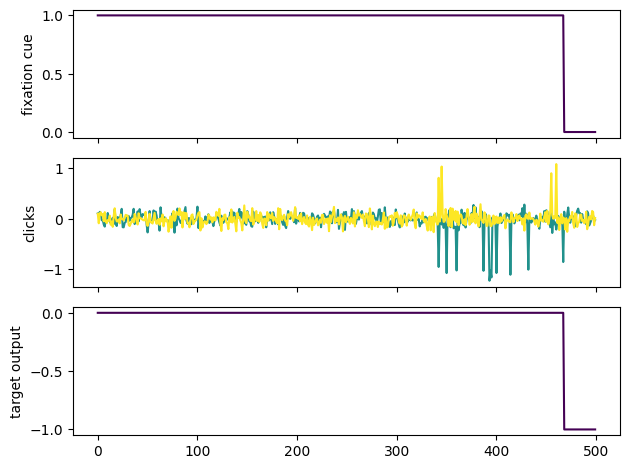

In [1]:
## Pclicks task - just like Luo et al 2023
from ctd.task_modeling.task_env.task_env import PClicks

pc = PClicks(n_timesteps= 500, noise= 0.1, rateL=30)  # Hz

pc.render()

pc_loss_func = pc.loss_func


## TT for all rateL

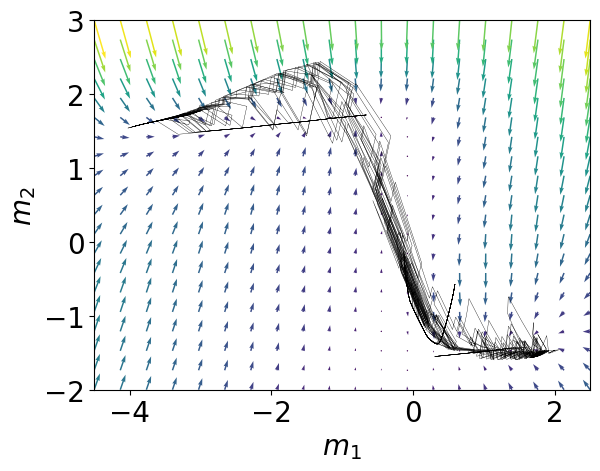

In [10]:
from ctd.comparison.analysis.tt.tt import Analysis_TT
import matplotlib.pyplot as plt
import numpy as np
import torch

node2_pc = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250331_PClicks_NODE_grid_allRates/max_epochs=800_weight_decay=1.00E-08_learning_rate=2.00E-03_seed=0_noise=0.00E+00_allRates=True_latent_size=2_layer_hidden_size=64_latent_l2_wt=1.00E-08"

node2_pc = Analysis_TT(run_name = "node1", filepath = node2_pc + "/")

node2_pc.plot_flow_field(latents_range = [[-4.5,2.5],[-2,3]], num_points = 20, inputs = torch.zeros(1,3), xstar=None, 
                        q_flag=None, colors_fps=None, num_traj=25, cmap=plt.cm.viridis, scatter_trajectories=False,
                        params = None, noiseless=False, intrinsic=False)


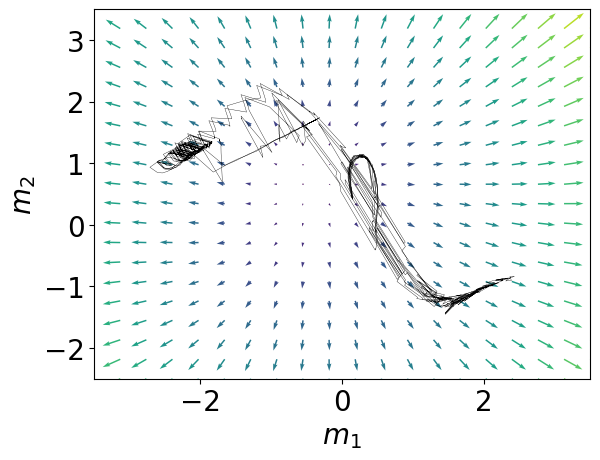

In [11]:
# say above is DD (stretch, would be a good one) and this one for TT (or viceversa)
import torch
import matplotlib.pyplot as plt
from ctd.comparison.analysis.tt.tt import Analysis_TT

node2_pc_worse = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250331_PClicks_NODE_grid_allRates/max_epochs=800_weight_decay=1.00E-08_learning_rate=2.00E-03_seed=0_noise=5.00E-02_allRates=True_latent_size=2_layer_hidden_size=64_latent_l2_wt=1.00E-08"

node2_pc_worse = Analysis_TT(run_name = "node1", filepath = node2_pc_worse + "/")
#torch.tensor([[0,1,0]])
node2_pc_worse.plot_flow_field(latents_range = [[-3.5,3.5],[-2.5,3.5]], num_points = 20, inputs = torch.tensor([[1,0,1]]), xstar=None, 
                        q_flag=None, colors_fps=None, num_traj=10, cmap=plt.cm.viridis, scatter_trajectories=False,
                        params = None, noiseless=False, intrinsic=True)

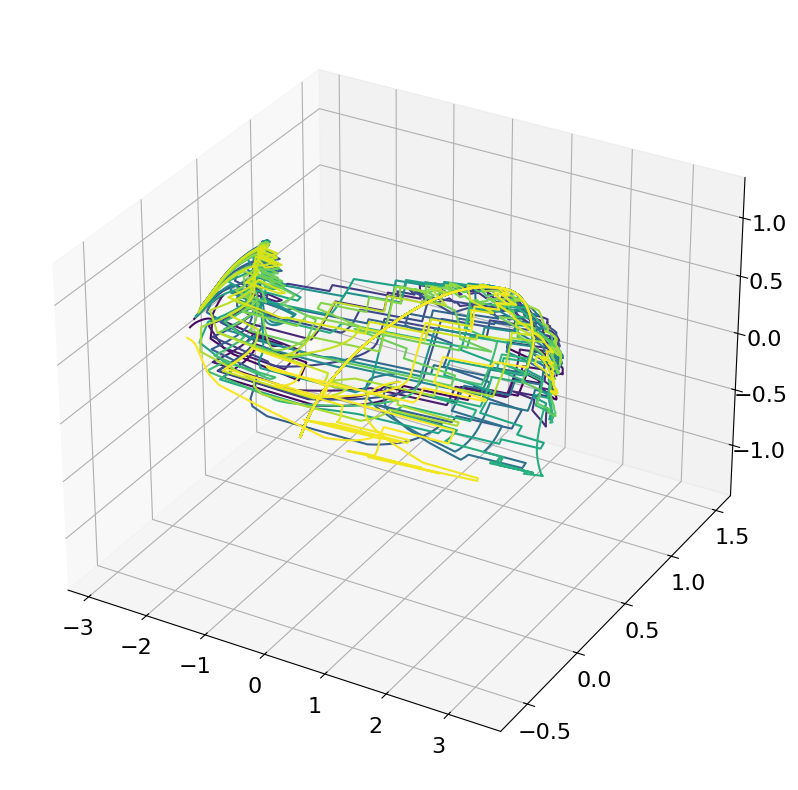

In [20]:
node3_pc_worse = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250331_PClicks_NODE_grid_allRates/max_epochs=800_weight_decay=1.00E-08_learning_rate=2.00E-03_seed=0_noise=0.00E+00_allRates=True_latent_size=3_layer_hidden_size=64_latent_l2_wt=1.00E-08"
node3_pc_worse = Analysis_TT(run_name = "node1", filepath = node3_pc_worse + "/")
node3_pc_worse.plot_trial_latents(num_trials=50, n_components=2)

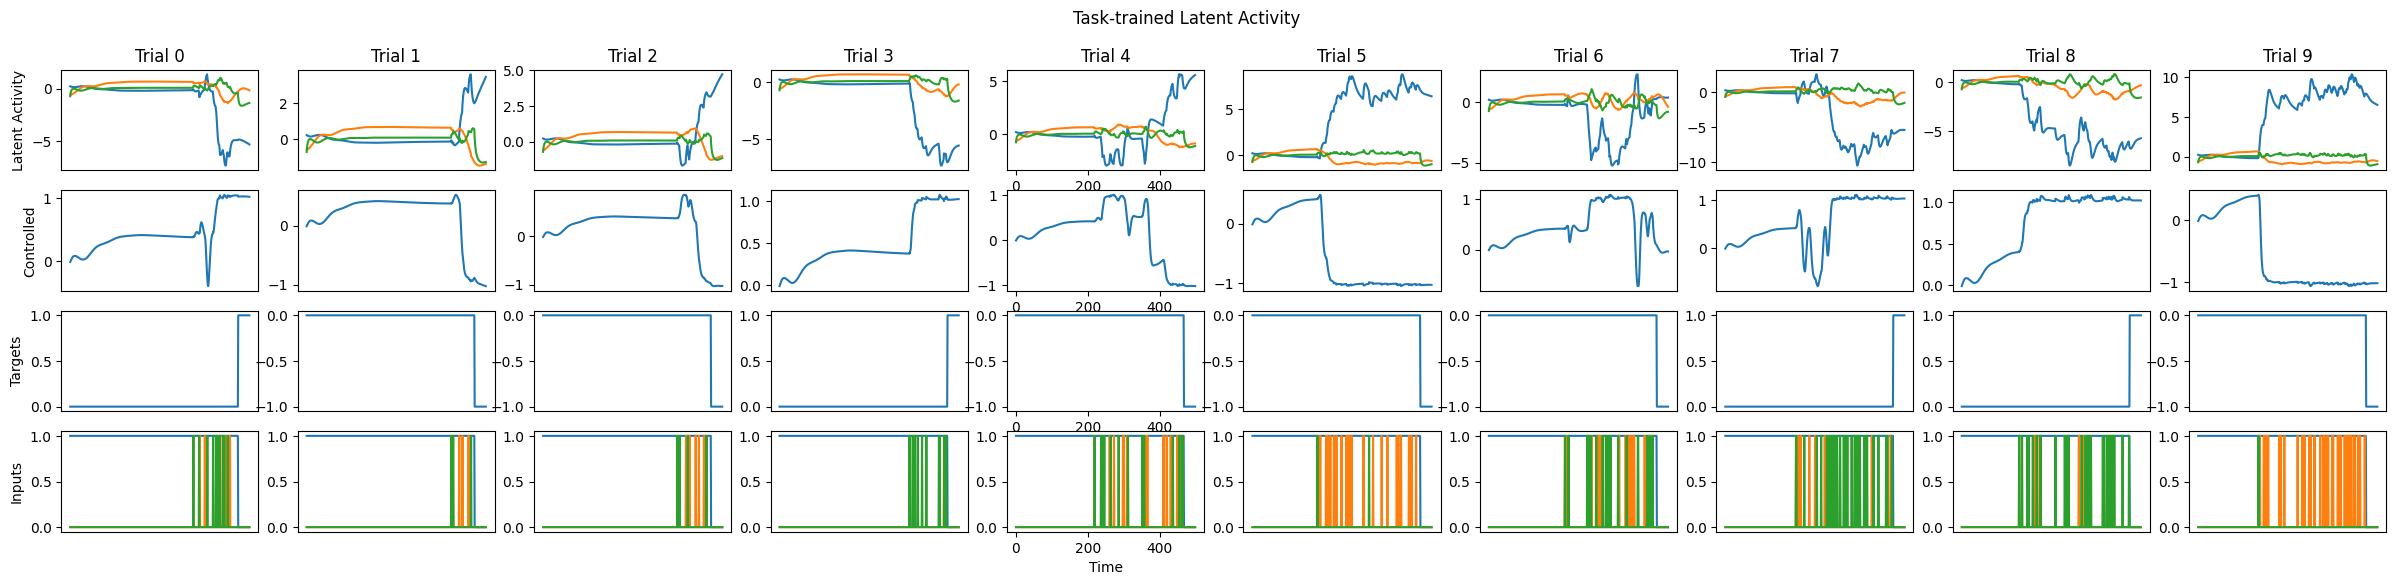

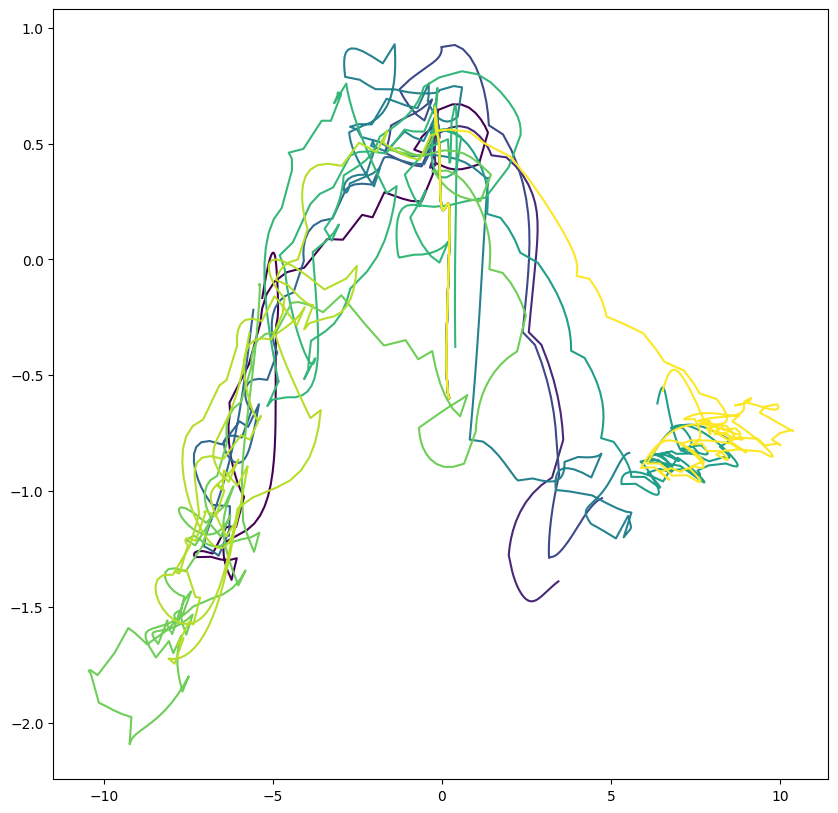

In [3]:
# loss 26 - does not solve it
fr2_pc = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250331_PClicks_fr_grid_allRates/max_epochs=800_weight_decay=1.00E-05_learning_rate=1.00E-03_noise=0.00E+00_allRates=True_seed=0_latent_size=2"
fr128_pc = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250331_PClicks_fr_grid_allRates/max_epochs=800_weight_decay=1.00E-05_learning_rate=1.00E-03_noise=0.00E+00_allRates=True_seed=0_latent_size=128"

# fr2_pc = Analysis_TT(run_name = "node1", filepath = fr2_pc + "/")
fr128_pc = Analysis_TT(run_name = "node1", filepath = fr128_pc + "/")

fr128_pc.plot_trial_io(num_trials=10)

# also showing PCA
fr128_pc.plot_trial_latents(num_trials=10, n_components=2)

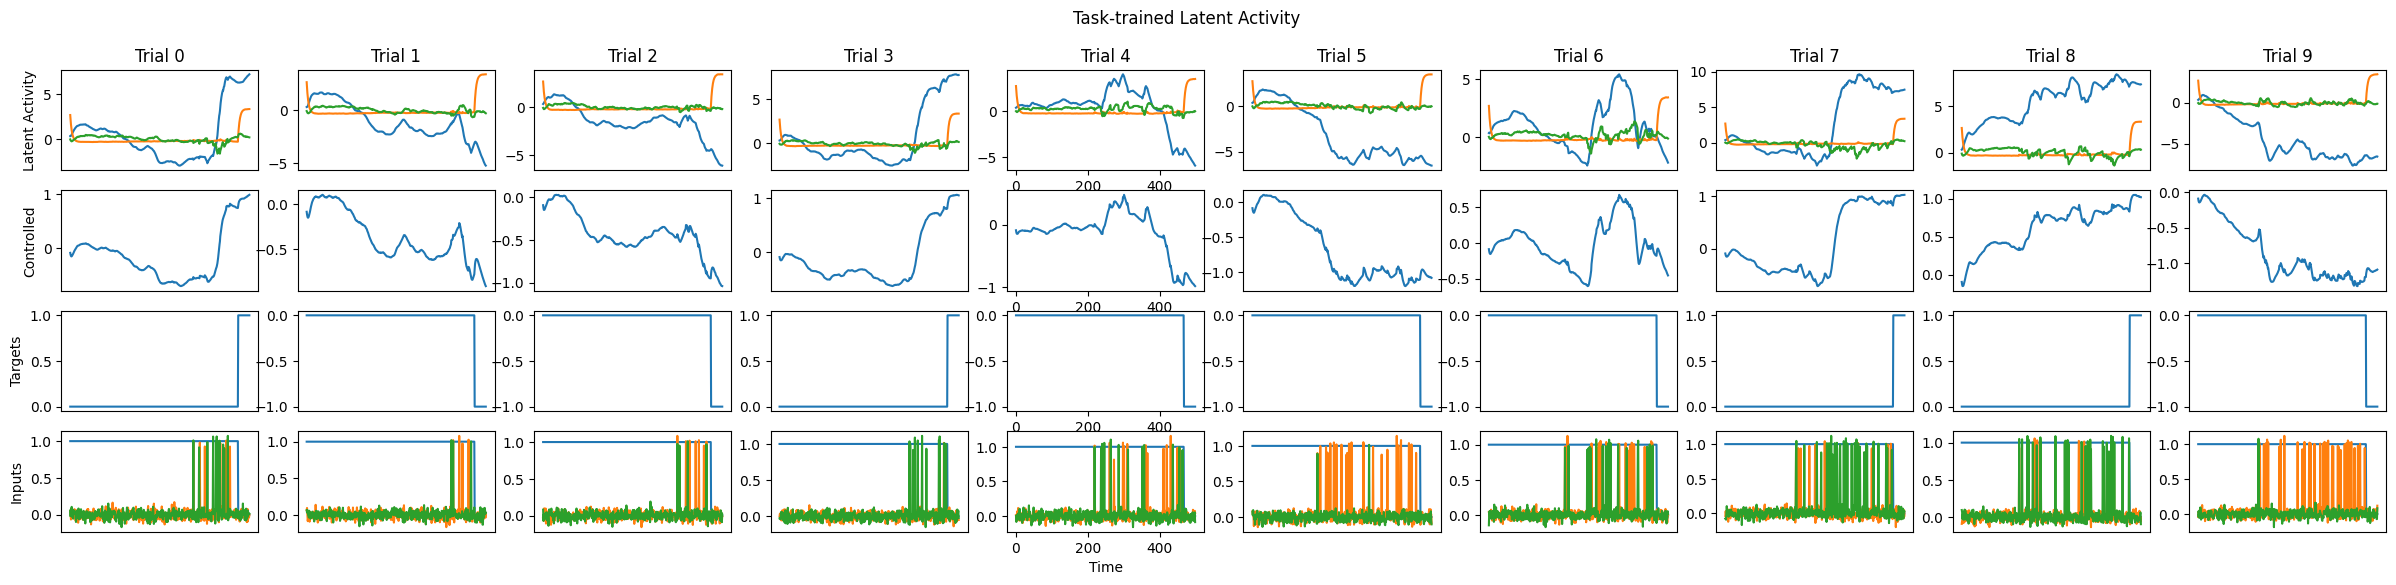

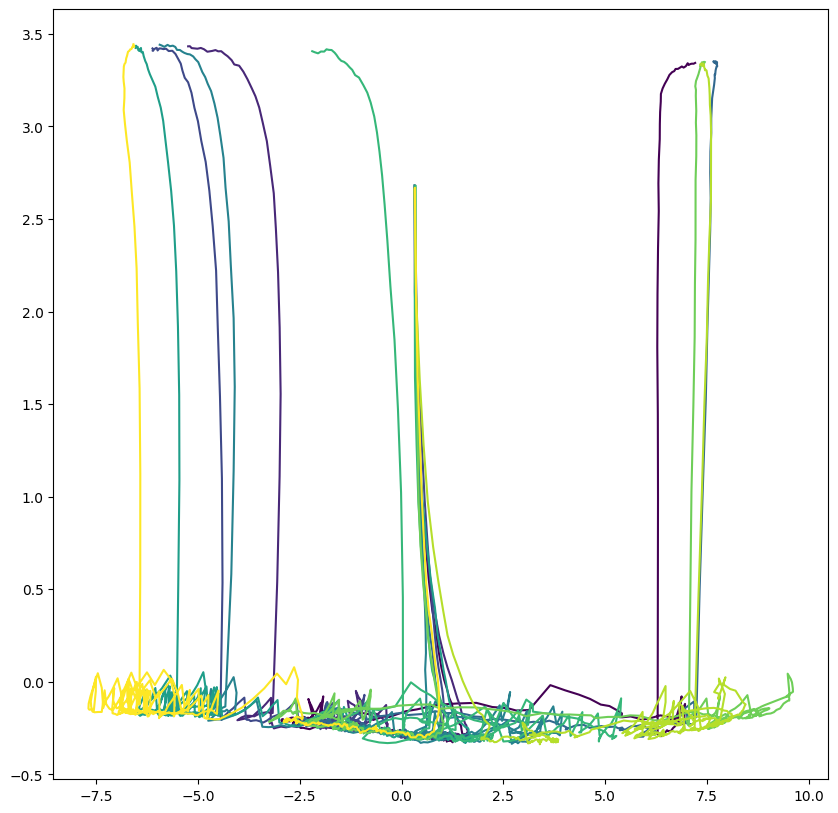

In [2]:
from ctd.comparison.analysis.tt.tt import Analysis_TT
lr128_pc = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250331_PClicks_lr_grid_allRates/max_epochs=800_weight_decay=1.00E-05_learning_rate=1.00E-04_noise=5.00E-02_allRates=True_seed=0_rank=2_latent_size=128"

lr128_pc = Analysis_TT(run_name = "lr128_pc", filepath = lr128_pc + "/")

lr128_pc.plot_trial_io(num_trials=10)

# also showing PCA
lr128_pc.plot_trial_latents(num_trials=10, n_components=2)

## TT for a single rateL 

Notice that

* easy trials actually have models perform worse when the latent size is too big
* the intrinsic flowfield is just (F,0), while the other one that I use has (F,input) - state, which is the same used for FP finder

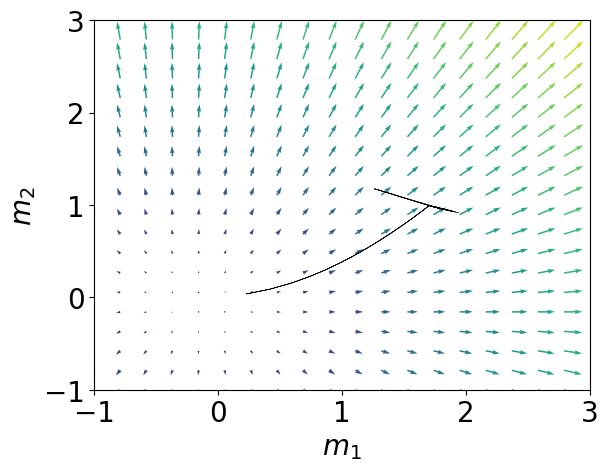

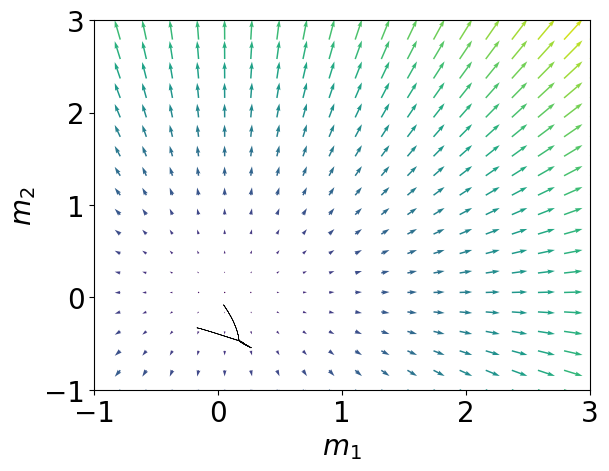

In [5]:
# first very short training on PClicks - loss was 0 always and something is prob wrong
from ctd.comparison.analysis.tt.tt import Analysis_TT
import matplotlib.pyplot as plt
import numpy as np
import torch

sweep = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250323_PClicks_NODE_grid"

# rateL=39

# rateL=14
r14 = "max_epochs=1000_weight_decay=1.00E-09_learning_rate=1.00E-03_seed=0_noise=0.00E+00_rateL=14_latent_size=2_layer_hidden_size=128_latent_l2_wt=1.00E-08"

# rateL=1
r1 = "max_epochs=1000_weight_decay=1.00E-09_learning_rate=1.00E-03_seed=0_noise=0.00E+00_rateL=1_latent_size=2_layer_hidden_size=128_latent_l2_wt=1.00E-08"

# rateL=26
r26 = "max_epochs=1000_weight_decay=1.00E-09_learning_rate=1.00E-03_seed=0_noise=0.00E+00_rateL=26_latent_size=2_layer_hidden_size=128_latent_l2_wt=1.00E-08"

# rate=32 MISSING SIM
r32 = "max_epochs=1000_weight_decay=1.00E-09_learning_rate=1.00E-03_seed=0_noise=0.00E+00_rateL=32_latent_size=2_layer_hidden_size=128_latent_l2_wt=1.00E-08"

# MANY MORE PC TT from 2 sweeps

node1 = Analysis_TT(run_name = "node1", filepath = sweep + "/" + r1 + "/")
node14 = Analysis_TT(run_name = "node14", filepath = sweep + "/" + r14 + "/")
node26 = Analysis_TT(run_name = "node32", filepath = sweep + "/" + r26 + "/")
# node32 = Analysis_TT(run_name = "node1", filepath = sweep + "/" + r32 + "/")

fr1 = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250329_PClicks_fr_grid_test/max_epochs=500_batch_size=256_weight_decay=1.00E-05_learning_rate=1.00E-03_noise=0.00E+00_rateL=1_seed=0_latent_size=2/"
fr1_ana = Analysis_TT(run_name = "fr1", filepath = fr1)

# node1.plot_trial_io(num_trials = 3)
# node14.plot_trial_io(num_trials = 3)
# node26.plot_trial_io(num_trials = 3)

# # NOTE that running pca takes maximum variance and plotting the trajectories might magnify any noise in them

# choose pca and/or tsne when >3 latents
# node1.plot_trial_latents(num_trials = 100, reduce_3_latents=False, pca=True)
# node14.plot_trial_latents(num_trials = 100, reduce_3_latents=False, pca=True)
# node26.plot_trial_latents(num_trials = 100, reduce_3_latents=False, pca=True)

# # NO FIXED POINTS SHOULD BE FOUND - then what is the point of DSAAAA
# # plot the trajs and fixed points
# node_pclicks_39_2lat.plot_fps(
#                     num_traj=10,
#                     n_inits=1024,
#                     noise_scale=0.0,
#                     learning_rate=1e-3,  # higher LR brings up spurious unstable points
#                     max_iters=10000,
#                     device="cpu",
#                     seed=0,
#                     compute_jacobians=True,
#                     q_thresh=1e-6,
#                     n_pca_components=3,
#                     return_pca_model = False,
#                     do_pca=False,
#                     plot_only_points=False,
#                     return_points = False,
#                 )

# MANUAL inputs: of shape (1, task_input_size)
fr1_ana.plot_flow_field(latents_range = [[-1,3],[-1,3]], num_points = 20, inputs = torch.zeros(1,3), xstar=None, 
                        q_flag=None, colors_fps=None, num_traj=10, cmap=plt.cm.viridis, scatter_trajectories=False,
                        params = None, noiseless=False, intrinsic=True)

# print(node1.get_loss(pc_loss_func))

# CHANGE THE M1, M2 LABELS - they are latent 1 and 2 literally


fr39 = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250329_PClicks_fr_grid_test/max_epochs=500_batch_size=256_weight_decay=1.00E-08_learning_rate=1.00E-04_noise=0.00E+00_rateL=39_seed=0_latent_size=2/"
fr39_ana = Analysis_TT(run_name = "fr39", filepath = fr39)
fr39_ana.plot_flow_field(latents_range = [[-1,3],[-1,3]], num_points = 20, inputs = torch.zeros(1,3), xstar=None, 
                        q_flag=None, colors_fps=None, num_traj=10, cmap=plt.cm.viridis, scatter_trajectories=False,
                        params = None, noiseless=False, intrinsic=True)

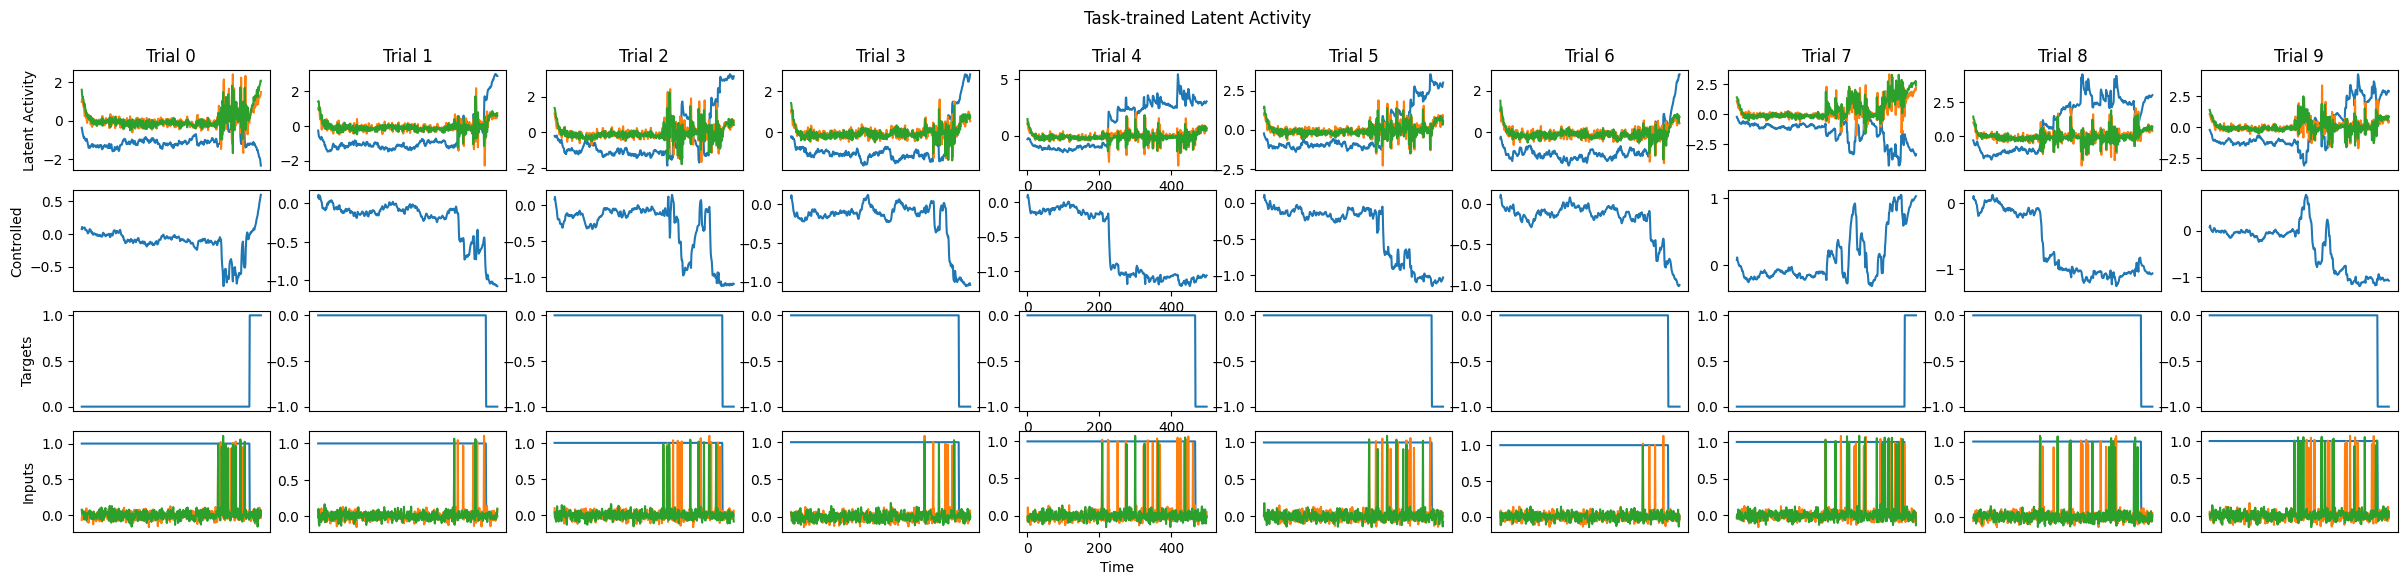

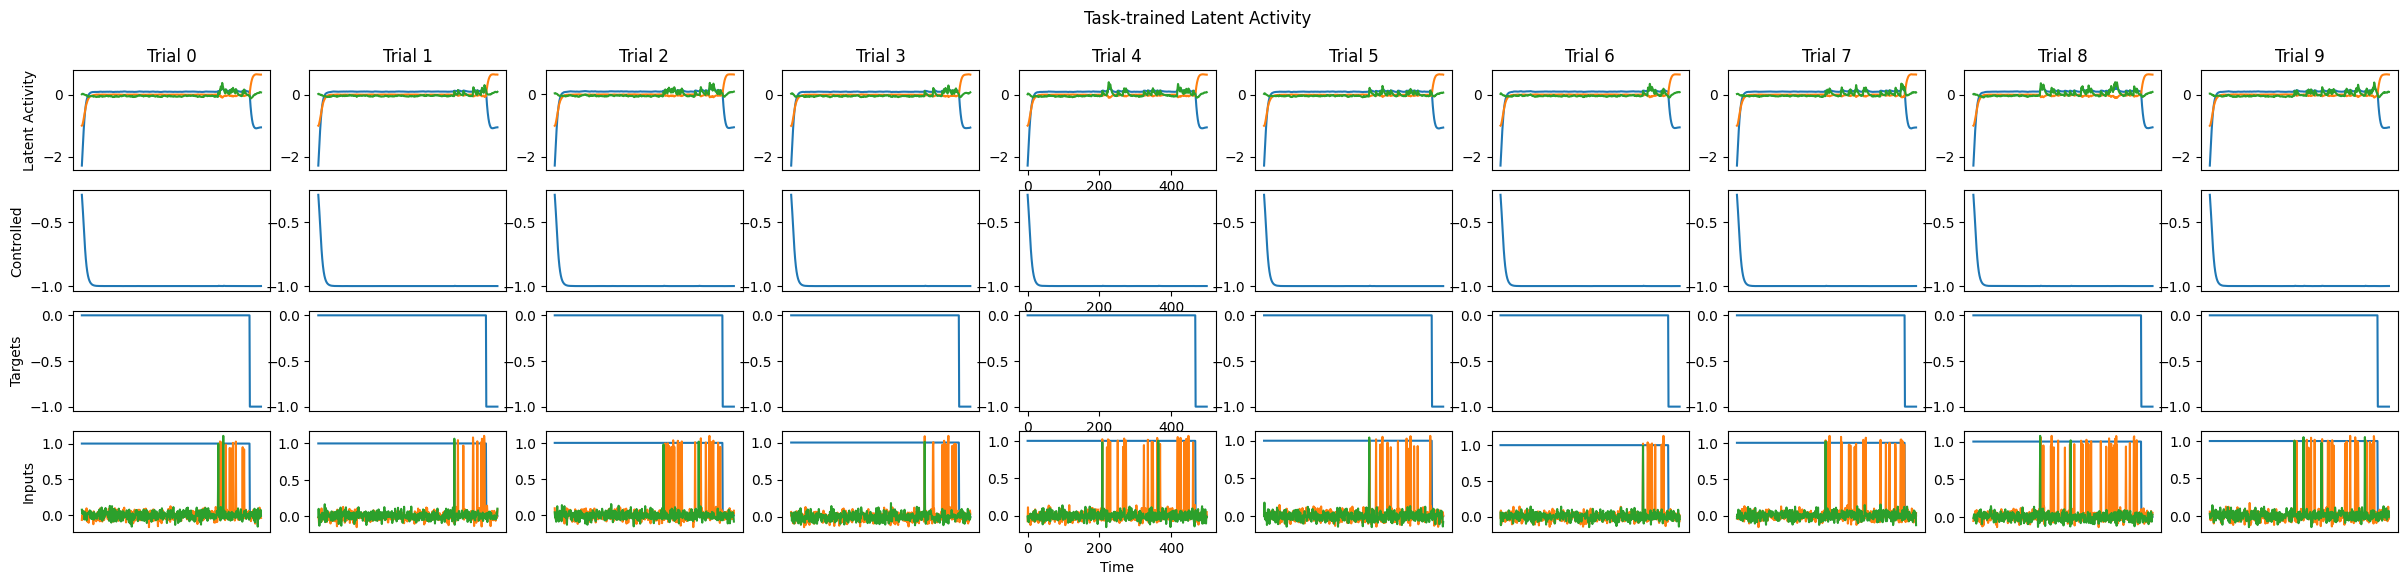

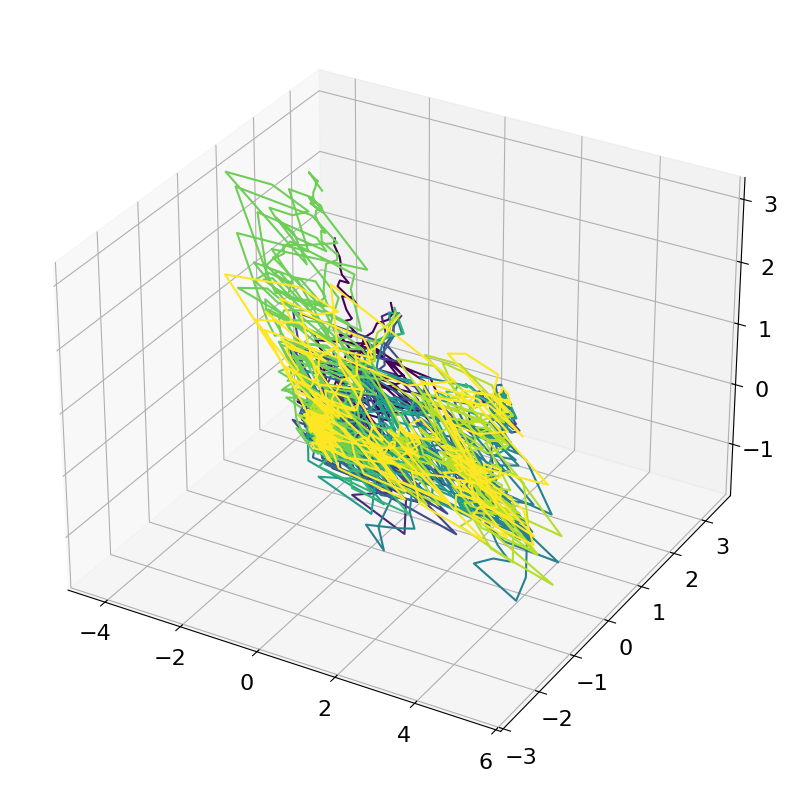

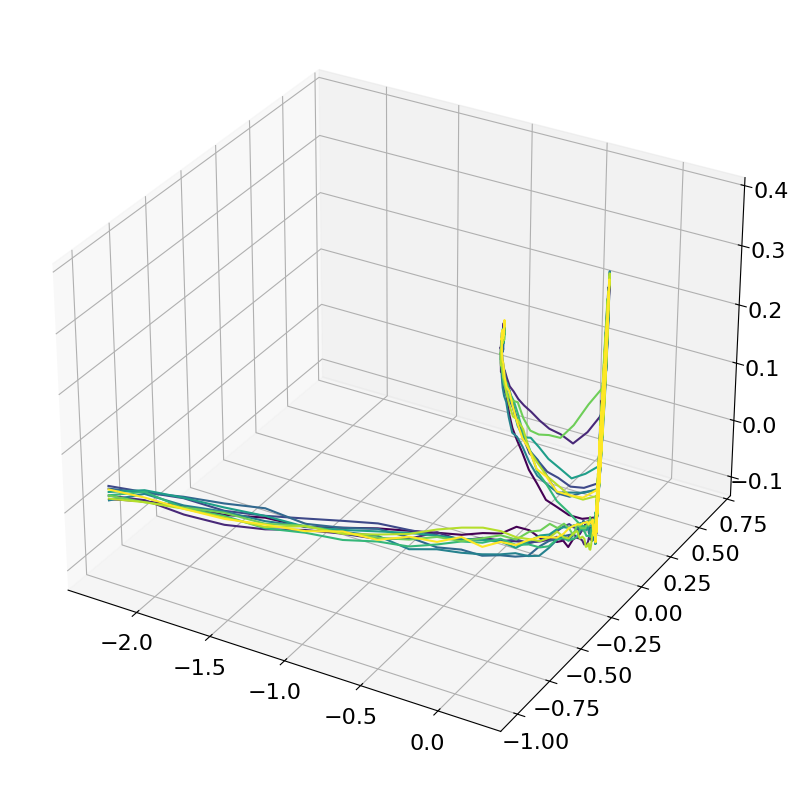

AttributeError: 'function' object has no attribute 'to'

In [3]:
# FullRankRNN

from ctd.comparison.analysis.tt.tt import Analysis_TT

# 26 not good
tune26 = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250318_PClicks_full_26/max_epochs=500_weight_decay=1.00E-06_learning_rate=1.00E-02_seed=0_noise=5.00E-02_rateL=26_latent_size=64"
# 39 good - tbh could just guess one side always and still not lose much
tune39 = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250318_PClicks_full_39/max_epochs=500_weight_decay=1.00E-06_learning_rate=1.00E-02_seed=0_noise=5.00E-02_rateL=39_latent_size=16"

full_pclicks_26 = Analysis_TT(run_name = "full_pclicks_26", filepath = tune26 + "/")
full_pclicks_39 = Analysis_TT(run_name = "full_pclicks_39", filepath = tune39 + "/")

# io is showing PCA latents
full_pclicks_26.plot_trial_io(num_trials=10)
full_pclicks_39.plot_trial_io(num_trials=10)

# also showing PCA
full_pclicks_26.plot_trial_latents(num_trials=10)
full_pclicks_39.plot_trial_latents(num_trials=10)

# plot the trajs and fixed points - NEED CELL
full_pclicks_39.plot_fps(
                    num_traj=10,
                    n_inits=2048,
                    noise_scale=0.0,
                    learning_rate=1e-3,  # higher LR brings up spurious unstable points
                    max_iters=10000,
                    device="cpu",
                    seed=0,
                    compute_jacobians=True,
                    q_thresh=1e-5,
                    n_pca_components=3,
                    return_pca_model = False,
                    do_pca=False,
                    plot_only_points=False,
                    return_points = False,
                )

In [ ]:
# visualize simulated neural dataset
import h5py

# LIKE THE LUO 2023 PAPER: simulate dataset with the same number of neurons, trials, and firing rate as the real data

# easy pclicks trials simulated from NODE
path = "/scratch/gpfs/ad2002/content/datasets/dt/20250316_PClicks_NODE/max_epochs=250_weight_decay=1.00E-10_learning_rate=1.00E-02_seed=0_noise=5.00E-02_rateL=39_latent_size=2_layer_hidden_size=64_latent_l2_wt=1.00E-10"
tune = "heldin_50_heldout_10_obs_noise_pseudoPoisson_dispersion_1.0_seed_0.h5"
sim_data = path + "/" + tune

# this is from the data_training datamodule
with h5py.File(data_path, "r") as h5file:
    # Load the data
    train_data = to_tensor(h5file["train_encod_data"][()])
    valid_data = to_tensor(h5file["valid_encod_data"][()])
    train_recon_data = to_tensor(h5file["train_recon_data"][()])
    valid_recon_data = to_tensor(h5file["valid_recon_data"][()])
    # Load the activity
    train_activity = to_tensor(h5file["train_activity"][()])
    valid_activity = to_tensor(h5file["valid_activity"][()])
    # Load the latents
    train_latents = to_tensor(h5file["train_latents"][()])
    valid_latents = to_tensor(h5file["valid_latents"][()])
    # Load the indices
    train_inds = to_tensor(h5file["train_inds"][()])
    valid_inds = to_tensor(h5file["valid_inds"][()])
    # Load other parameters
    self.orig_mean = h5file["orig_mean"][()]
    self.orig_std = h5file["orig_std"][()]
    self.readout = h5file["readout"][()]
    train_inputs = h5file["train_inputs"][()]
    valid_inputs = h5file["valid_inputs"][()]
    train_extra = h5file["train_extra"][()]
    valid_extra = h5file["valid_extra"][()]

## Marino Pagan task

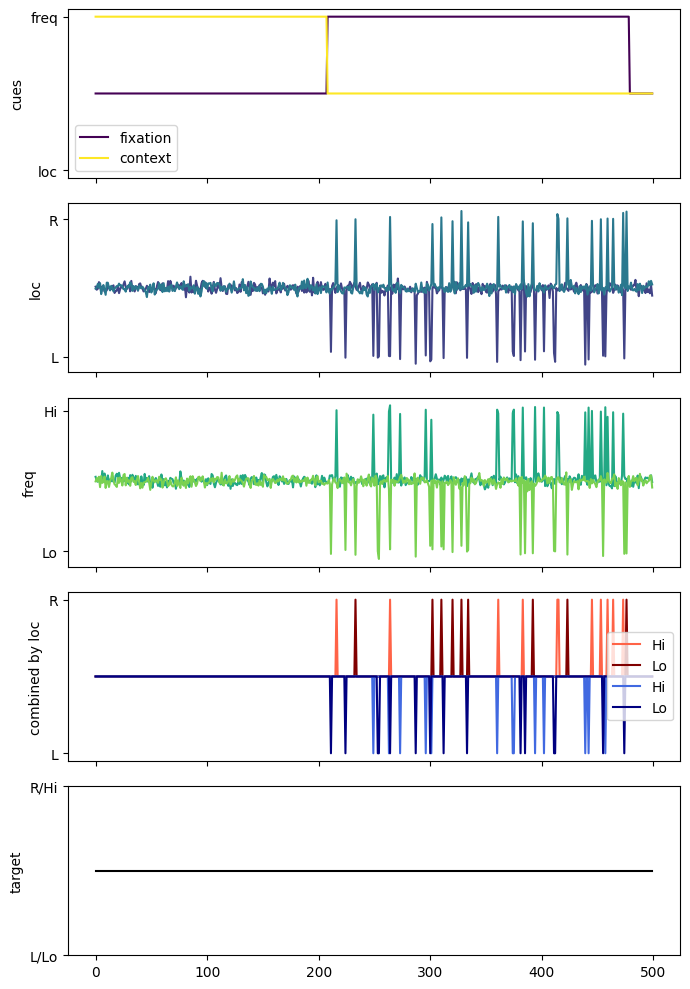

In [8]:
## Marino Pagan task - just like the paper
# note that there is a very small but non-zero chance that the target output should be 0 (if everything has tied)

from ctd.task_modeling.task_env.task_env import MarinoPagan

mp = MarinoPagan(n_timesteps= 500, noise= 0.05, rateL=20)  # Hz

mp.render()

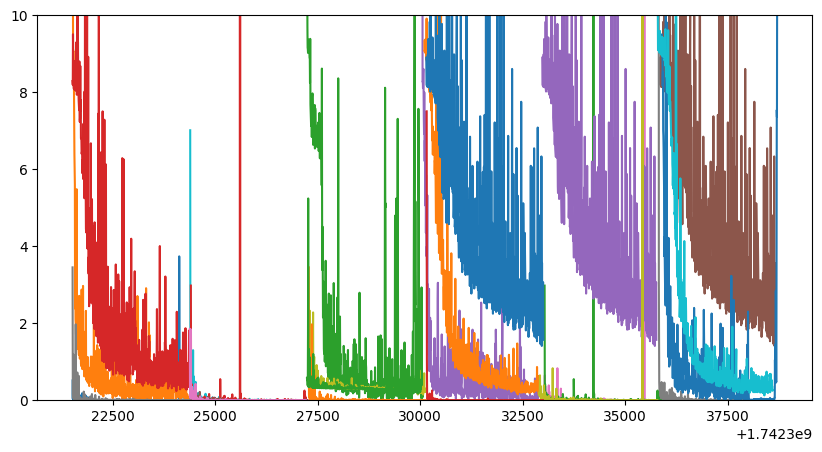

In [13]:
# compare the training dynamics of all tunes for one model on one task
import pandas as pd
import matplotlib.pyplot as plt
import os

def find_progress_files(directory):
    progress_files = []
    labels = []
    
    for folder in os.listdir(directory):
        folder_path = os.path.join(directory, folder)
        progress_file = os.path.join(folder_path, 'progress.csv')
        
        if os.path.isdir(folder_path) and os.path.isfile(progress_file) and os.path.getsize(progress_file) > 0:
            progress_files.append(progress_file)
            labels.append(folder_path)
    
    return progress_files, labels

# partial NODE in TEST
# dir = "/scratch/gpfs/ad2002/content/runs/task-trained/20250316_PClicks_NODE/train_2025-03-16_21-29-27/"

# full NODE in SHARE - the second blue explodes in gradient: rate 1, latent 10 - got 24 out of the total 48, but prob can get one of each 
# type save the learning rate...
dir = "/scratch/gpfs/ad2002/content/runs/task-trained/20250318_PClicks_NODE_full/train_2025-03-18_14-11-40"

fig, ax = plt.subplots(figsize=(10, 5))
progress_files, labels = find_progress_files(dir)
for i in range(len(progress_files)):  
    file = progress_files[i]
    df = pd.read_csv(file)
    ax.plot(df['timestamp'], df['loss'], label=labels[i])
    #ax.legend()

ax.set_ylim([0, 10])

plt.show()

# plotting both easy and hard trials: for easy size 2 lr 1e-2 is the best (3-10 not necesarily better, but higher lr means more spikey),
# for 26 size 10 is best

# could increase the lat weight to make the latents more stable